In [1]:
import sys, pickle
import random as _random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from floorplan_diffusion.data.dataset import (
    ResPlanDataset, MAX_NUM_POINTS, CORNER_IDX_DIMS, ROOM_IDX_DIMS,
    _normalize_keys, ROOM_TYPE_TO_INT,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"
%matplotlib inline

print("Ready.")

Ready.


In [2]:
# Map every type int the encoder can emit back to a name (incl. window=5).
ROOM_TYPE_INT_TO_NAME = {v: k for k, v in ROOM_TYPE_TO_INT.items()}

ROOM_COLORS = {
    "living":     "#E07B54",
    "bedroom":    "#F5C96A",
    "kitchen":    "#A8C5A0",
    "bathroom":   "#88B4D4",
    "balcony":    "#C9A8E0",
    "window":     "#3CB4C4",  # openings we specifically want to track
    "door":       "#888888",
    "front_door": "#444444",
}

OPENINGS = ("door", "front_door", "window")

def decode_plan(arr, cond):
    """Reconstruct per-part (corners, name) from an augmented (arr, cond) pair."""
    coords = arr.T.copy()
    real_mask = cond["src_key_padding_mask"] < 0.5
    room_type_oh = cond["room_types"]
    room_idx_oh  = cond["room_indices"]

    rooms = {}
    for i in np.where(real_mask)[0]:
        rtype_int = int(np.argmax(room_type_oh[i]))
        ridx      = int(np.argmax(room_idx_oh[i]))
        rooms.setdefault((ridx, rtype_int), []).append(coords[i])

    return [(np.array(pts), ROOM_TYPE_INT_TO_NAME.get(rtype_int, str(rtype_int)))
            for (ridx, rtype_int), pts in sorted(rooms.items())]


def render_decoded(rooms, title, ax):
    ax.set_title(title, fontsize=9)
    ax.set_aspect("equal")
    ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
    ax.axhline(0, color="#ccc", lw=0.5); ax.axvline(0, color="#ccc", lw=0.5)
    for pts, name in rooms:
        color = ROOM_COLORS.get(name, "#cccccc")
        if len(pts) >= 3:
            ax.add_patch(plt.Polygon(pts, closed=True, fc=color, ec="black",
                                     alpha=0.6, lw=0.8, label=name))
        ax.scatter(pts[:, 0], pts[:, 1], s=12, c="black", zorder=3)
        # Mark opening centroids so they are easy to follow across rotations.
        if name in OPENINGS:
            cx, cy = pts.mean(axis=0)
            marker_color = {"front_door": "red", "door": "orange", "window": "blue"}[name]
            ax.plot(cx, cy, "x", ms=8, mew=2, color=marker_color, zorder=4)

print("Helpers ready.")

Helpers ready.


In [3]:
PKL_PATH = PROJECT_ROOT / "data" / "raw" / "ResPlan.pkl"

# Load raw plan dicts only — building the full ResPlanDataset materialises a
# 192x192x3 float64 mask stack per plan (~85 MB/plan) and OOMs. We only need one.
with open(PKL_PATH, "rb") as f:
    raw_plans = pickle.load(f)

WINDOW_TYPE_INT     = ROOM_TYPE_TO_INT["window"]      # 5
DOOR_TYPE_INT       = ROOM_TYPE_TO_INT["door"]        # 11
FRONT_DOOR_TYPE_INT = ROOM_TYPE_TO_INT["front_door"]  # 13

# A bare instance so we can call _process_plan without the heavy __init__.
ds = ResPlanDataset.__new__(ResPlanDataset)
ds.set_name = "train"          # augmentation active
ds.num_coords = 2
ds.max_num_points = MAX_NUM_POINTS

RT_END = 2 + 25
PAD_COL = RT_END + CORNER_IDX_DIMS + ROOM_IDX_DIMS

def encoded_type_ints(house_array):
    """Set of room-type ints present among the real (non-padded) points."""
    real = house_array[:, PAD_COL] > 0.5
    return set(np.argmax(house_array[real, 2:RT_END], axis=1).tolist())


In [4]:

# ── Score every plan for "simplicity" ────────────────────────────────────────
# Score = total_corners + angle_penalty
#   total_corners : sum of exterior vertices across all room polygons
#   angle_penalty : for each corner, abs deviation from nearest 90° multiple,
#                   summed across all corners — rewards axis-aligned walls.
#
# Lower score = simpler plan. We score from raw Shapely geoms so we never
# need to build the full ResPlanDataset (avoids the OOM we hit earlier).

from shapely.geometry import Polygon, MultiPolygon
import numpy as np

ROOM_KEYS = ["living", "bedroom", "kitchen", "bathroom", "balcony", "window"]

def _polygons_from_geom(geom):
    if geom is None:
        return []
    if isinstance(geom, Polygon):
        return [] if geom.is_empty else [geom]
    if isinstance(geom, MultiPolygon):
        return [g for g in geom.geoms if not g.is_empty]
    if hasattr(geom, "geoms"):
        return [g for g in geom.geoms if isinstance(g, Polygon) and not g.is_empty]
    return []

def angle_penalty(corners: np.ndarray) -> float:
    """Sum of |deviation from nearest 90°| for every interior angle (degrees)."""
    n = len(corners)
    if n < 3:
        return 0.0
    total = 0.0
    for i in range(n):
        p0 = corners[(i - 1) % n]
        p1 = corners[i]
        p2 = corners[(i + 1) % n]
        v1 = p0 - p1
        v2 = p2 - p1
        norm = np.linalg.norm(v1) * np.linalg.norm(v2)
        if norm < 1e-9:
            continue
        cos_a = np.clip(np.dot(v1, v2) / norm, -1, 1)
        angle_deg = np.degrees(np.arccos(cos_a))
        # deviation from nearest multiple of 90°
        nearest_90 = round(angle_deg / 90) * 90
        total += abs(angle_deg - nearest_90)
    return total

def simplicity_score(plan: dict) -> float:
    plan = _normalize_keys(plan.copy())
    total_corners = 0
    total_penalty = 0.0
    for key in ROOM_KEYS:
        for poly in _polygons_from_geom(plan.get(key)):
            corners = np.array(poly.exterior.coords[:-1])
            total_corners += len(corners)
            total_penalty += angle_penalty(corners)
    # Normalise penalty to same scale as corner count (penalty in degrees)
    return total_corners + total_penalty / 90.0

print("Scoring all plans…")
scores = [(i, simplicity_score(p)) for i, p in enumerate(raw_plans)]
scores.sort(key=lambda x: x[1])
print(f"Done. Score range: {scores[0][1]:.1f} – {scores[-1][1]:.1f}")
print(f"Total plans scored: {len(scores)}")


Scoring all plans…
Done. Score range: 28.0 – 964.5
Total plans scored: 17107


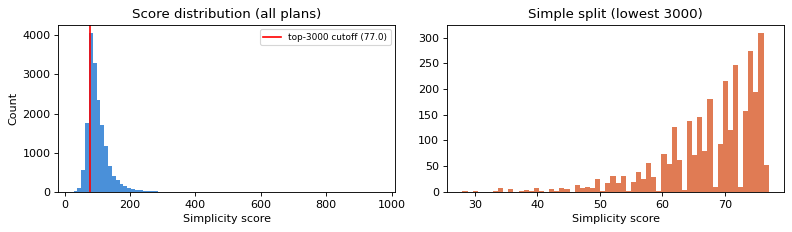

Simple  cutoff score : 77.00
Complex plans        : 14107


In [5]:

# ── Inspect the score distribution ───────────────────────────────────────────

all_scores = [s for _, s in scores]

fig, axes = plt.subplots(1, 2, figsize=(10, 3), dpi=80)

axes[0].hist(all_scores, bins=80, color="#4A90D9", edgecolor="none")
axes[0].axvline(all_scores[2999], color="red", lw=1.5, label=f"top-3000 cutoff ({all_scores[2999]:.1f})")
axes[0].set_xlabel("Simplicity score"); axes[0].set_ylabel("Count")
axes[0].set_title("Score distribution (all plans)"); axes[0].legend(fontsize=8)

# Zoom into the simple tail
axes[1].hist(all_scores[:3000], bins=60, color="#E07B54", edgecolor="none")
axes[1].set_xlabel("Simplicity score")
axes[1].set_title("Simple split (lowest 3000)")

plt.tight_layout()
plt.savefig("score_distribution.png", dpi=80, bbox_inches="tight")
plt.show()

print(f"Simple  cutoff score : {all_scores[2999]:.2f}")
print(f"Complex plans        : {len(scores) - 3000}")


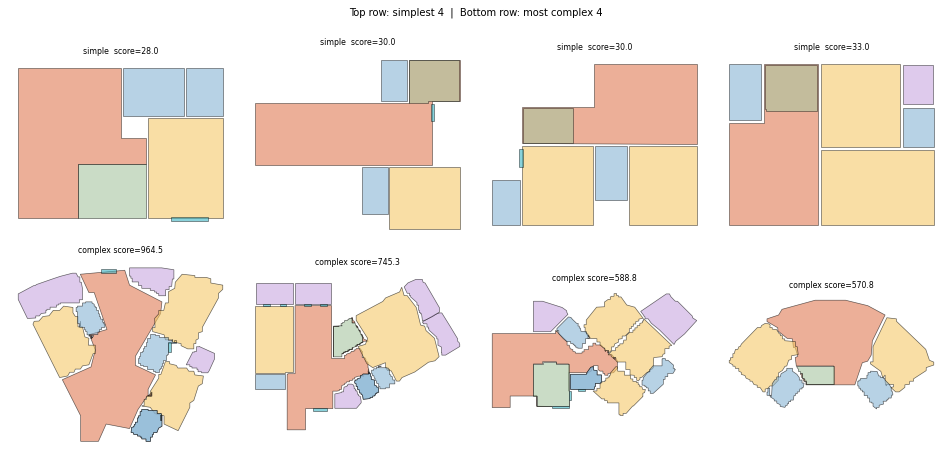

In [6]:

# ── Quick visual sanity check: 4 simple vs 4 complex plans ───────────────────

from floorplan_diffusion.data.dataset import _simplify_polygon, ROOM_TYPE_TO_INT

def render_raw_plan(plan, title, ax, max_corners=64):
    """Render directly from raw Shapely geoms (no dataset overhead)."""
    plan = _normalize_keys(plan.copy())
    ax.set_title(title, fontsize=7)
    ax.set_aspect("equal"); ax.axis("off")
    colors = {"living":"#E07B54","bedroom":"#F5C96A","kitchen":"#A8C5A0",
              "bathroom":"#88B4D4","balcony":"#C9A8E0","window":"#3CB4C4"}
    for key, color in colors.items():
        for poly in _polygons_from_geom(plan.get(key)):
            poly = _simplify_polygon(poly, max_corners)
            xs, ys = poly.exterior.xy
            ax.fill(xs, ys, fc=color, ec="black", alpha=0.6, lw=0.6)

N = 4
fig, axes = plt.subplots(2, N, figsize=(N * 3, 6), dpi=80)
fig.suptitle("Top row: simplest 4  |  Bottom row: most complex 4", fontsize=9)

for col in range(N):
    simple_idx,  s_score  = scores[col]
    complex_idx, c_score  = scores[-(col + 1)]
    render_raw_plan(raw_plans[simple_idx],  f"simple  score={s_score:.1f}", axes[0][col])
    render_raw_plan(raw_plans[complex_idx], f"complex score={c_score:.1f}", axes[1][col])

plt.tight_layout()
plt.savefig("simple_vs_complex.png", dpi=80, bbox_inches="tight")
plt.show()


In [7]:

# ── Save the two splits as separate pickle files ──────────────────────────────

N_SIMPLE = 3000

simple_indices  = {idx for idx, _ in scores[:N_SIMPLE]}
complex_indices = {idx for idx, _ in scores[N_SIMPLE:]}

simple_plans  = [raw_plans[i] for i in sorted(simple_indices)]
complex_plans = [raw_plans[i] for i in sorted(complex_indices)]

out_dir = PROJECT_ROOT / "data" / "raw"
simple_path  = out_dir / "ResPlan_simple.pkl"
complex_path = out_dir / "ResPlan_complex.pkl"

with open(simple_path, "wb") as f:
    pickle.dump(simple_plans, f)
print(f"Saved {len(simple_plans):,} simple plans  → {simple_path}")

with open(complex_path, "wb") as f:
    pickle.dump(complex_plans, f)
print(f"Saved {len(complex_plans):,} complex plans → {complex_path}")


Saved 3,000 simple plans  → /zhome/70/7/219373/Floorplan-Diffusion-Models/data/raw/ResPlan_simple.pkl
Saved 14,107 complex plans → /zhome/70/7/219373/Floorplan-Diffusion-Models/data/raw/ResPlan_complex.pkl
